# HW14 - embeddings, FAISS, retrieval evaluation and mini-RAG

В этой работе я собрал небольшой учебный pipeline для semantic retrieval и mini-RAG на локальной базе знаний по теме retrieval и RAG.

Что будет в ноутбуке:
- подготовка компактной базы знаний;
- чанкинг документов;
- TF-IDF эмбеддинги и индекс `FAISS`;
- проверка retrieval на контрольных запросах;
- небольшой эксперимент по `chunk_size`;
- обновление базы знаний и переиндексация;
- mini-RAG с возвратом источников.

Все артефакты сохраняются в `homeworks/HW14/artifacts/`.

In [8]:
from pathlib import Path
import platform
import random
import re
import sys

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "HW14" and (CURRENT_DIR / "artifacts").exists():
    HW_DIR = CURRENT_DIR
elif (CURRENT_DIR / "homeworks" / "HW14").exists():
    HW_DIR = CURRENT_DIR / "homeworks" / "HW14"
else:
    HW_DIR = CURRENT_DIR

ARTIFACTS_DIR = HW_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

env_info = pd.Series(
    {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
        "faiss": faiss.__version__,
        "device": "CPU",
        "seed": SEED,
        "hw_dir": str(HW_DIR),
    }
)

env_info

python                                              3.12.10
platform                          Windows-11-10.0.26100-SP0
numpy                                                 2.4.1
pandas                                                2.3.3
sklearn                                               1.8.0
faiss                                                1.13.2
device                                                  CPU
seed                                                     42
hw_dir      C:\Users\Maken\Desktop\AI-course\homeworks\HW14
dtype: object

In [9]:
initial_documents = [
    {
        "doc_id": "doc_01",
        "title": "Embeddings as semantic vectors",
        "text": "Текстовые эмбеддинги позволяют перевести фрагменты текста в плотное векторное пространство, где семантически близкие высказывания оказываются рядом. Это важно для retrieval, потому что пользователь и база знаний часто используют разные формулировки одной и той же идеи. Если искать только по точным словам, система пропустит полезный фрагмент, когда слова в запросе и документе не совпали буквально. Векторное представление помогает сравнивать именно смысловую близость. На практике эмбеддинги полезны тогда, когда нужно искать ответы по статьям, справке, FAQ или внутренним инструкциям, а формулировки вопросов заранее не фиксированы.",
    },
    {
        "doc_id": "doc_02",
        "title": "Why FAISS is useful",
        "text": "FAISS нужен для быстрого поиска ближайших векторов. В учебной работе корпус маленький, поэтому поиск можно было бы сделать и полным перебором, но использование FAISS полезно как инженерная привычка и как обязательный элемент pipeline. Если векторы нормализованы, то inner product в `IndexFlatIP` соответствует cosine similarity. Для небольшого корпуса такой индекс подходит лучше всего: он простой, воспроизводимый и не требует сложной настройки. В более крупных системах FAISS позволяет масштабировать retrieval без изменения общей логики: документы превращаются в векторы, векторы индексируются, затем для каждого запроса система быстро возвращает top-k кандидатов.",
    },
    {
        "doc_id": "doc_03",
        "title": "Chunking strategy",
        "text": "Чанкинг нужен потому, что целый документ часто слишком широкий для точного retrieval. Если индексировать только целые документы, ответ будет опираться на слишком большой и шумный контекст. Если же разбивать текст на умеренные фрагменты, retriever может вернуть именно ту часть знания, которая связана с вопросом. Размер чанка влияет на баланс между полнотой и точностью. Слишком маленькие чанки теряют смысловой контекст, а слишком большие начинают смешивать несколько тем сразу. Небольшой overlap полезен, потому что он уменьшает риск разрыва важной мысли на границе соседних фрагментов и делает поиск стабильнее.",
    },
    {
        "doc_id": "doc_04",
        "title": "Top-k and context quality",
        "text": "Параметр top-k определяет, сколько фрагментов retriever возвращает дальше в систему. Маленький top-k делает контекст компактным, но можно потерять полезный фрагмент. Слишком большой top-k повышает recall, но часто добавляет лишний шум в контекст и ухудшает итоговый ответ. Для mini-RAG это особенно заметно: генератор или extractive answer builder начинает опираться не только на нужные предложения, но и на соседние темы. Поэтому top-k удобно подбирать не только по retrieval-метрикам, но и по качеству конечного ответа. В учебных сценариях разумно начинать с 3-5 фрагментов и смотреть, как меняется устойчивость результата.",
    },
    {
        "doc_id": "doc_05",
        "title": "Retrieval metrics",
        "text": "Для базовой оценки retrieval обычно считают hit@k, recall@k и MRR@k. Метрика hit@k отвечает на вопрос, попал ли хотя бы один релевантный источник в top-k. Recall@k показывает, какую долю всех релевантных источников система успела вернуть в top-k. MRR@k учитывает позицию первого правильного источника и поэтому чувствительна к ранжированию. Если правильный документ стоит на первом месте, вклад в MRR выше, чем если он появился только на третьей позиции. Даже на маленьком учебном benchmark набор этих метрик полезен: он позволяет не гадать на глаз, а сравнивать retrieval по понятным числам.",
    },
    {
        "doc_id": "doc_06",
        "title": "TF-IDF versus dense embeddings",
        "text": "TF-IDF остается хорошим baseline для retrieval, особенно когда корпус небольшой, тема узкая, а важные термины явно повторяются в вопросах и документах. Такой подход прост, быстр и полностью воспроизводим. Dense embeddings обычно выигрывают там, где нужно лучше ловить переформулировки и скрытое семантическое сходство. Но для учебного ноутбука TF-IDF удобен тем, что не требует скачивания тяжелой модели и все равно позволяет построить корректный retrieval pipeline с векторами и индексом FAISS. Поэтому TF-IDF можно считать не упрощением ради галочки, а нормальным инженерным baseline, который честно показывает, как устроен контур поиска.",
    },
    {
        "doc_id": "doc_07",
        "title": "Knowledge base update and reindexing",
        "text": "Если база знаний меняется, retriever нужно обновлять вместе с ней. Недостаточно просто добавить новый текст в список документов: нужно снова выполнить чанкинг, заново построить векторы и переиндексировать их в FAISS. Иначе новые документы вообще не попадут в поиск, а старый индекс будет отражать устаревшее состояние базы знаний. В учебной работе удобно показывать это на нескольких новых документах и специально подобранных запросах. После переиндексации можно сравнить retrieval до и после обновления и увидеть, что система начинает находить те темы, которых раньше в базе знаний просто не было.",
    },
    {
        "doc_id": "doc_08",
        "title": "Why sources matter",
        "text": "Возврат источников вместе с ответом делает mini-RAG более прозрачным. Пользователь видит, на какие документы и фрагменты система опиралась, и может быстро проверить ответ. Это особенно полезно, когда ответ частичный или когда вопрос сформулирован неоднозначно. Источники помогают отличить grounded answer от свободной генерации без опоры на базу знаний. Кроме того, наличие ссылок на retrieved chunks облегчает отладку: если ответ плохой, можно понять, ошибка возникла на этапе retrieval, на этапе сборки контекста или уже на этапе генерации. Для учебного проекта возврат источников является важной частью интерпретируемости решения.",
    },
    {
        "doc_id": "doc_09",
        "title": "Noisy context and failure cases",
        "text": "Даже если в top-k попал правильный документ, итоговый ответ может испортиться из-за шумного контекста. В одном и том же наборе retrieved chunks могут одновременно лежать релевантные предложения и отвлекающие подробности. Если answer builder выбирает не те предложения, он сформирует расплывчатый или частично неверный ответ. Еще одна типичная проблема связана с формулировкой вопроса: короткие и слишком общие запросы обычно извлекают более общий контекст. Поэтому retrieval нужно оценивать отдельно, а потом дополнительно смотреть на качество итогового ответа. Хороший mini-RAG зависит не только от наличия правильного документа, но и от аккуратной сборки контекста.",
    },
    {
        "doc_id": "doc_10",
        "title": "Designing a small FAQ corpus",
        "text": "Небольшая база знаний работает лучше, когда документы оформлены единообразно: у каждого текста есть понятный заголовок, одна главная тема и достаточно явные формулировки. Для FAQ полезно избегать дублирования почти одинаковых ответов и длинных документов, где смешано слишком много подтем. Если одна тема повторяется в нескольких местах, retrieval начинает возвращать дубликаты и ранжирование становится менее устойчивым. Для учебного mini-RAG лучше выбрать компактный, тематически цельный корпус из 10-15 документов. Тогда легче проверять retrieval, подбирать параметры чанкинга и анализировать ошибки без лишнего шума со стороны самих данных.",
    },
    {
        "doc_id": "doc_11",
        "title": "Mini-RAG pipeline",
        "text": "Базовый mini-RAG можно описать как последовательность шагов: пользователь задает вопрос, retriever находит top-k релевантных чанков, затем из этих чанков собирается контекст, а поверх контекста строится ответ. В простом учебном варианте ответ может быть не генеративным, а extractive: система выбирает несколько наиболее подходящих предложений из retrieved context и объединяет их в короткий grounded answer. Такой подход проще отлаживать, потому что видно, какие именно предложения попали в финальный ответ. Кроме того, он снижает риск галлюцинаций по сравнению со свободной генерацией без контекста и хорошо подходит для первой практики по RAG.",
    },
    {
        "doc_id": "doc_12",
        "title": "How to judge answer quality",
        "text": "Качество mini-RAG удобно анализировать отдельно от retrieval. Даже если retriever работает неплохо, answer builder может потерять важную деталь, смешать несколько соседних идей или дать слишком общий ответ. Поэтому полезно смотреть на 3-5 конкретных примеров вопросов и проверять, достаточно ли ответ точный, grounded и понятный. В учебной работе разумно описывать не только успешные кейсы, но и проблемные: где вопрос оказался слишком общим, где нужный фрагмент был найден, но не попал в ответ, и где база знаний сама оказалась неполной. Такой разбор помогает честно показать ограничения решения.",
    },
]

new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Hybrid search",
        "text": "Гибридный поиск сочетает keyword search и векторный retrieval. Такой подход полезен, когда в части запросов важны точные термины, названия сущностей или специальные аббревиатуры, а в другой части важнее смысловая близость. Если использовать только dense или только sparse подход, система может терять один из этих сигналов. В учебном mini-RAG гибридный поиск не обязателен, но его полезно добавить в базу знаний как идею для расширения. На практике hybrid search часто повышает устойчивость retrieval на смешанных запросах, где одновременно есть редкие ключевые слова и свободная формулировка вопроса.",
    },
    {
        "doc_id": "doc_14",
        "title": "Refusal when evidence is weak",
        "text": "Если retrieved context не дает достаточных оснований для уверенного ответа, mini-RAG не должен отвечать слишком смело. Более безопасная стратегия состоит в том, чтобы явно сказать, что в найденном контексте недостаточно подтверждений, и предложить уточнить вопрос или расширить базу знаний. Такой режим отказа особенно важен там, где пользователю нужен grounded answer, а не правдоподобная догадка. Даже простой extractive RAG выигрывает от этого правила: система становится честнее, а ее ответы легче интерпретировать. Фактически это не лечит retrieval, но снижает ущерб от слабого retrieval или неполной базы знаний.",
    },
    {
        "doc_id": "doc_15",
        "title": "Chunk metadata and deduplication",
        "text": "Metadata чанков помогают объяснять retrieval и контролировать качество контекста. Если вместе с текстом хранить `doc_id`, заголовок, номер чанка и позицию в исходном документе, то легче отлаживать ранжирование, показывать источники и анализировать ошибки. Удаление почти одинаковых чанков и дубликатов тоже полезно: оно уменьшает шум в top-k и делает выдачу разнообразнее. Когда база знаний растет, без metadata и deduplication все сложнее понимать, почему retriever выбрал именно эти фрагменты. Поэтому даже в маленьком учебном проекте стоит хранить понятные идентификаторы и хотя бы базово следить за дублированием.",
    },
]

docs_df = pd.DataFrame(initial_documents)
docs_df["n_words"] = docs_df["text"].str.split().str.len()

print(f"Исходных документов: {len(initial_documents)}")
print(f"Суммарный объем корпуса: {docs_df['n_words'].sum()} слов")

display(docs_df[["doc_id", "title", "n_words"]])
display(docs_df.loc[:2, ["doc_id", "title", "text"]])

Исходных документов: 12
Суммарный объем корпуса: 1033 слов


,doc_id,title,n_words
0,doc_01,Embeddings as semantic vectors,83
1,doc_02,Why FAISS is useful,87
2,doc_03,Chunking strategy,86
3,doc_04,Top-k and context quality,86
4,doc_05,Retrieval metrics,87
5,doc_06,TF-IDF versus dense embeddings,87
6,doc_07,Knowledge base update and reindexing,86
7,doc_08,Why sources matter,85
8,doc_09,Noisy context and failure cases,90
9,doc_10,Designing a small FAQ corpus,83


,doc_id,title,text
0,doc_01,Embeddings as semantic vectors,"Текстовые эмбеддинги позволяют перевести фрагменты текста в плотное векторное пространство, где семантически близкие..."
1,doc_02,Why FAISS is useful,"FAISS нужен для быстрого поиска ближайших векторов. В учебной работе корпус маленький, поэтому поиск можно было бы с..."
2,doc_03,Chunking strategy,"Чанкинг нужен потому, что целый документ часто слишком широкий для точного retrieval. Если индексировать только целы..."


In [10]:
def make_chunks(documents, chunk_size=55, overlap=10):
    rows = []
    step = max(1, chunk_size - overlap)

    for doc in documents:
        words = doc["text"].split()
        for chunk_idx, start in enumerate(range(0, len(words), step), start=1):
            chunk_words = words[start : start + chunk_size]
            if not chunk_words:
                continue

            rows.append(
                {
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx:02d}",
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_index": chunk_idx,
                    "start_word": start,
                    "end_word": start + len(chunk_words),
                    "text": " ".join(chunk_words),
                }
            )

            if start + chunk_size >= len(words):
                break

    return pd.DataFrame(rows)


def build_retriever(documents, chunk_size=55, overlap=10):
    chunks_df = make_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    chunk_vectors = vectorizer.fit_transform(chunks_df["text"]).astype(np.float32).toarray()
    chunk_vectors = normalize(chunk_vectors, norm="l2").astype(np.float32)

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return {
        "documents": documents,
        "chunk_size": chunk_size,
        "overlap": overlap,
        "chunks_df": chunks_df,
        "vectorizer": vectorizer,
        "chunk_vectors": chunk_vectors,
        "index": index,
    }


def search_chunks(query, retriever, top_k=3):
    query_vector = retriever["vectorizer"].transform([query]).astype(np.float32).toarray()
    query_vector = normalize(query_vector, norm="l2").astype(np.float32)

    scores, indices = retriever["index"].search(query_vector, top_k)
    results = retriever["chunks_df"].iloc[indices[0]].copy().reset_index(drop=True)
    results["score"] = scores[0]
    return results[["chunk_id", "doc_id", "title", "score", "text"]]


def unique_doc_order(results_df):
    ordered = []
    for doc_id in results_df["doc_id"]:
        if doc_id not in ordered:
            ordered.append(doc_id)
    return ordered


def format_sources(doc_ids):
    return " | ".join(doc_ids)


base_chunk_size = 55
base_overlap = 10
base_top_k = 3
base_retriever = build_retriever(initial_documents, chunk_size=base_chunk_size, overlap=base_overlap)
chunks_df = base_retriever["chunks_df"]

print(f"Число чанков: {len(chunks_df)}")
print(f"Средняя длина чанка: {chunks_df['text'].str.split().str.len().mean():.1f} слов")

display(chunks_df.head(8))
display(chunks_df[chunks_df["doc_id"] == "doc_03"][ ["chunk_id", "text"] ])

sample_queries = [
    "зачем нужны текстовые эмбеддинги",
    "что нужно сделать после обновления базы знаний",
    "почему важно возвращать источники в mini-RAG",
    "как chunk size влияет на retrieval",
]

for query in sample_queries:
    print(f"\nЗапрос: {query}")
    display(search_chunks(query, base_retriever, top_k=base_top_k))

Число чанков: 24
Средняя длина чанка: 48.0 слов


,chunk_id,doc_id,title,chunk_index,start_word,end_word,text
0,doc_01_chunk_01,doc_01,Embeddings as semantic vectors,1,0,55,"Текстовые эмбеддинги позволяют перевести фрагменты текста в плотное векторное пространство, где семантически близкие..."
1,doc_01_chunk_02,doc_01,Embeddings as semantic vectors,2,45,83,когда слова в запросе и документе не совпали буквально. Векторное представление помогает сравнивать именно смысловую...
2,doc_02_chunk_01,doc_02,Why FAISS is useful,1,0,55,"FAISS нужен для быстрого поиска ближайших векторов. В учебной работе корпус маленький, поэтому поиск можно было бы с..."
3,doc_02_chunk_02,doc_02,Why FAISS is useful,2,45,87,"небольшого корпуса такой индекс подходит лучше всего: он простой, воспроизводимый и не требует сложной настройки. В ..."
4,doc_03_chunk_01,doc_03,Chunking strategy,1,0,55,"Чанкинг нужен потому, что целый документ часто слишком широкий для точного retrieval. Если индексировать только целы..."
5,doc_03_chunk_02,doc_03,Chunking strategy,2,45,86,"чанка влияет на баланс между полнотой и точностью. Слишком маленькие чанки теряют смысловой контекст, а слишком боль..."
6,doc_04_chunk_01,doc_04,Top-k and context quality,1,0,55,"Параметр top-k определяет, сколько фрагментов retriever возвращает дальше в систему. Маленький top-k делает контекст..."
7,doc_04_chunk_02,doc_04,Top-k and context quality,2,45,86,"builder начинает опираться не только на нужные предложения, но и на соседние темы. Поэтому top-k удобно подбирать не..."


,chunk_id,text
4,doc_03_chunk_01,"Чанкинг нужен потому, что целый документ часто слишком широкий для точного retrieval. Если индексировать только целы..."
5,doc_03_chunk_02,"чанка влияет на баланс между полнотой и точностью. Слишком маленькие чанки теряют смысловой контекст, а слишком боль..."



Запрос: зачем нужны текстовые эмбеддинги


,chunk_id,doc_id,title,score,text
0,doc_01_chunk_01,doc_01,Embeddings as semantic vectors,0.181607,"Текстовые эмбеддинги позволяют перевести фрагменты текста в плотное векторное пространство, где семантически близкие..."
1,doc_01_chunk_02,doc_01,Embeddings as semantic vectors,0.060527,когда слова в запросе и документе не совпали буквально. Векторное представление помогает сравнивать именно смысловую...
2,doc_02_chunk_01,doc_02,Why FAISS is useful,0.000000,"FAISS нужен для быстрого поиска ближайших векторов. В учебной работе корпус маленький, поэтому поиск можно было бы с..."


...

,chunk_id,doc_id,title,score,text
0,doc_07_chunk_02,doc_07,Knowledge base update and reindexing,0.324342,базы знаний. В учебной работе удобно показывать это на нескольких новых документах и специально подобранных запросах...
1,doc_07_chunk_01,doc_07,Knowledge base update and reindexing,0.143614,"Если база знаний меняется, retriever нужно обновлять вместе с ней. Недостаточно просто добавить новый текст в список..."
2,doc_02_chunk_01,doc_02,Why FAISS is useful,0.040732,"FAISS нужен для быстрого поиска ближайших векторов. В учебной работе корпус маленький, поэтому поиск можно было бы с..."



Запрос: почему важно возвращать источники в mini-RAG


,chunk_id,doc_id,title,score,text
0,doc_10_chunk_02,doc_10,Designing a small FAQ corpus,0.124400,retrieval начинает возвращать дубликаты и ранжирование становится менее устойчивым. Для учебного mini-RAG лучше выбр...
1,doc_08_chunk_01,doc_08,Why sources matter,0.118753,"Возврат источников вместе с ответом делает mini-RAG более прозрачным. Пользователь видит, на какие документы и фрагм..."
2,doc_09_chunk_02,doc_09,Noisy context and failure cases,0.072546,одна типичная проблема связана с формулировкой вопроса: короткие и слишком общие запросы обычно извлекают более общи...



Запрос: как chunk size влияет на retrieval


,chunk_id,doc_id,title,score,text
0,doc_03_chunk_01,doc_03,Chunking strategy,0.159650,"Чанкинг нужен потому, что целый документ часто слишком широкий для точного retrieval. Если индексировать только целы..."
1,doc_03_chunk_02,doc_03,Chunking strategy,0.155187,"чанка влияет на баланс между полнотой и точностью. Слишком маленькие чанки теряют смысловой контекст, а слишком боль..."
2,doc_04_chunk_02,doc_04,Top-k and context quality,0.093821,"builder начинает опираться не только на нужные предложения, но и на соседние темы. Поэтому top-k удобно подбирать не..."


In [11]:
benchmark_queries = pd.DataFrame(
    [
        {"query": "зачем переводить текст в векторное пространство", "expected_sources": ["doc_01"]},
        {"query": "почему размер чанка влияет на retrieval", "expected_sources": ["doc_03"]},
        {"query": "как top-k связан с качеством контекста", "expected_sources": ["doc_04", "doc_11"]},
        {"query": "какие метрики нужны для оценки retrieval", "expected_sources": ["doc_05"]},
        {"query": "когда TF-IDF подходит как baseline", "expected_sources": ["doc_06"]},
        {"query": "что делать после добавления новых документов", "expected_sources": ["doc_07"]},
        {"query": "зачем возвращать источники вместе с ответом", "expected_sources": ["doc_08", "doc_11"]},
        {"query": "почему шумный контекст портит итоговый ответ", "expected_sources": ["doc_09"]},
        {"query": "как оформить небольшой FAQ корпус", "expected_sources": ["doc_10"]},
        {"query": "из каких шагов состоит mini-RAG", "expected_sources": ["doc_11"]},
    ]
)


def evaluate_query(query, expected_sources, retriever, top_k=3):
    retrieved = search_chunks(query, retriever, top_k=top_k)
    retrieved_sources = unique_doc_order(retrieved)
    expected_set = set(expected_sources)
    hit = int(any(source in expected_set for source in retrieved_sources))
    overlap = sum(source in expected_set for source in retrieved_sources)
    recall = overlap / len(expected_sources)
    rank = next((idx + 1 for idx, source in enumerate(retrieved_sources) if source in expected_set), None)
    mrr = 0.0 if rank is None else 1.0 / rank

    return {
        "query": query,
        "expected_source": format_sources(expected_sources),
        "retrieved_sources": format_sources(retrieved_sources),
        "hit_at_k": hit,
        "recall_at_k": recall,
        "rank_of_first_relevant": rank,
        "mrr_at_k": mrr,
    }


results_rows = [
    evaluate_query(row.query, row.expected_sources, base_retriever, top_k=base_top_k)
    for row in benchmark_queries.itertuples(index=False)
]
retrieval_eval_df = pd.DataFrame(results_rows)
retrieval_eval_path = ARTIFACTS_DIR / "retrieval_eval.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame(
    [
        {
            "metric": "hit@k",
            "value": retrieval_eval_df["hit_at_k"].mean(),
        },
        {
            "metric": "recall@k",
            "value": retrieval_eval_df["recall_at_k"].mean(),
        },
        {
            "metric": "MRR@k",
            "value": retrieval_eval_df["mrr_at_k"].mean(),
        },
    ]
)

print(f"Файл сохранен: {retrieval_eval_path}")
display(retrieval_eval_df)
display(summary_df)

hard_cases = retrieval_eval_df.sort_values(["hit_at_k", "rank_of_first_relevant"], ascending=[True, False]).head(3)
print("Потенциально проблемные запросы:")
display(hard_cases)

Файл сохранен: C:\Users\Maken\Desktop\AI-course\homeworks\HW14\artifacts\retrieval_eval.csv


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,зачем переводить текст в векторное пространство,doc_01,doc_01 | doc_07,1,1.0,1.0,1.000000
1,почему размер чанка влияет на retrieval,doc_03,doc_03 | doc_05,1,1.0,1.0,1.000000
2,как top-k связан с качеством контекста,doc_04 | doc_11,doc_11 | doc_04,1,1.0,1.0,1.000000
3,какие метрики нужны для оценки retrieval,doc_05,doc_05 | doc_11 | doc_08,1,1.0,1.0,1.000000
4,когда TF-IDF подходит как baseline,doc_06,doc_06 | doc_02,1,1.0,1.0,1.000000
5,что делать после добавления новых документов,doc_07,doc_07 | doc_10,1,1.0,1.0,1.000000
6,зачем возвращать источники вместе с ответом,doc_08 | doc_11,doc_08 | doc_10 | doc_07,1,0.5,1.0,1.000000
7,почему шумный контекст портит итоговый ответ,doc_09,doc_04 | doc_03 | doc_09,1,1.0,3.0,0.333333
8,как оформить небольшой FAQ корпус,doc_10,doc_02 | doc_06 | doc_01,0,0.0,NaN,0.000000
9,из каких шагов состоит mini-RAG,doc_11,doc_11 | doc_10 | doc_09,1,1.0,1.0,1.000000


,metric,value
0,hit@k,0.900000
1,recall@k,0.850000
2,MRR@k,0.833333


Потенциально проблемные запросы:


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
8,как оформить небольшой FAQ корпус,doc_10,doc_02 | doc_06 | doc_01,0,0.0,NaN,0.000000
7,почему шумный контекст портит итоговый ответ,doc_09,doc_04 | doc_03 | doc_09,1,1.0,3.0,0.333333
0,зачем переводить текст в векторное пространство,doc_01,doc_01 | doc_07,1,1.0,1.0,1.000000


,chunk_size,overlap,n_chunks,hit_at_k,recall_at_k,mrr_at_k
0,45,10,36,0.9,0.85,0.833333
1,70,10,24,1.0,0.95,0.866667


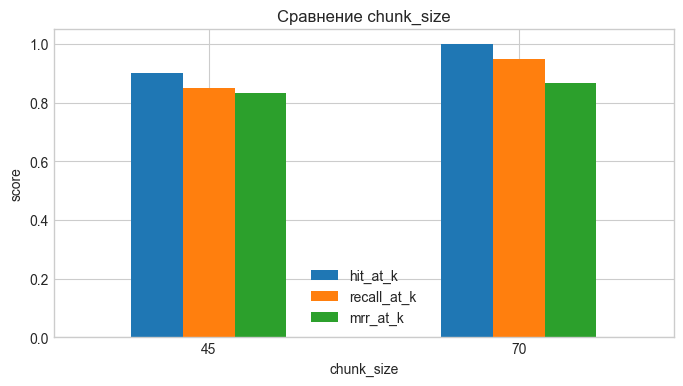

Основной вариант для дальнейших шагов: chunk_size=70, overlap=10


In [12]:
experiment_rows = []

for tested_chunk_size in [45, 70]:
    tested_retriever = build_retriever(initial_documents, chunk_size=tested_chunk_size, overlap=10)
    tested_eval = pd.DataFrame(
        [
            evaluate_query(row.query, row.expected_sources, tested_retriever, top_k=base_top_k)
            for row in benchmark_queries.itertuples(index=False)
        ]
    )

    experiment_rows.append(
        {
            "chunk_size": tested_chunk_size,
            "overlap": 10,
            "n_chunks": len(tested_retriever["chunks_df"]),
            "hit_at_k": tested_eval["hit_at_k"].mean(),
            "recall_at_k": tested_eval["recall_at_k"].mean(),
            "mrr_at_k": tested_eval["mrr_at_k"].mean(),
        }
    )

experiment_df = pd.DataFrame(experiment_rows).sort_values("chunk_size")
display(experiment_df)

ax = experiment_df.plot(x="chunk_size", y=["hit_at_k", "recall_at_k", "mrr_at_k"], kind="bar", figsize=(8, 4))
ax.set_title("Сравнение chunk_size")
ax.set_ylabel("score")
plt.xticks(rotation=0)
plt.show()

best_row = experiment_df.sort_values(["hit_at_k", "mrr_at_k", "n_chunks"], ascending=[False, False, True]).iloc[0]
main_chunk_size = int(best_row["chunk_size"])
main_overlap = int(best_row["overlap"])
main_retriever = build_retriever(initial_documents, chunk_size=main_chunk_size, overlap=main_overlap)

print(f"Основной вариант для дальнейших шагов: chunk_size={main_chunk_size}, overlap={main_overlap}")

In [13]:
update_queries = pd.DataFrame(
    [
        {
            "query": "когда полезно сочетать keyword search и векторный retrieval",
            "expected_sources": ["doc_13"],
        },
        {
            "query": "как mini-RAG должен вести себя если доказательств недостаточно",
            "expected_sources": ["doc_14"],
        },
        {
            "query": "зачем хранить metadata чанков и удалять дубликаты",
            "expected_sources": ["doc_15"],
        },
        {
            "query": "почему после расширения базы знаний нужна переиндексация",
            "expected_sources": ["doc_07"],
        },
    ]
)

updated_documents = initial_documents + new_documents
updated_retriever = build_retriever(updated_documents, chunk_size=main_chunk_size, overlap=main_overlap)

extended_benchmark = pd.concat([benchmark_queries, update_queries], ignore_index=True)

before_extended_df = pd.DataFrame(
    [
        evaluate_query(row.query, row.expected_sources, main_retriever, top_k=base_top_k)
        for row in extended_benchmark.itertuples(index=False)
    ]
)
after_extended_df = pd.DataFrame(
    [
        evaluate_query(row.query, row.expected_sources, updated_retriever, top_k=base_top_k)
        for row in extended_benchmark.itertuples(index=False)
    ]
)

before_after_rows = []
for row in update_queries.itertuples(index=False):
    before_row = evaluate_query(row.query, row.expected_sources, main_retriever, top_k=base_top_k)
    after_row = evaluate_query(row.query, row.expected_sources, updated_retriever, top_k=base_top_k)
    before_after_rows.append(
        {
            "query": row.query,
            "before_retrieved_sources": before_row["retrieved_sources"],
            "after_retrieved_sources": after_row["retrieved_sources"],
            "changed": before_row["retrieved_sources"] != after_row["retrieved_sources"],
            "before_hit_at_k": before_row["hit_at_k"],
            "after_hit_at_k": after_row["hit_at_k"],
            "expected_source": before_row["expected_source"],
        }
    )

retrieval_before_after_df = pd.DataFrame(before_after_rows)
retrieval_before_after_path = ARTIFACTS_DIR / "retrieval_before_after_update.csv"
retrieval_before_after_df.to_csv(retrieval_before_after_path, index=False, encoding="utf-8-sig")

comparison_summary = pd.DataFrame(
    [
        {
            "stage": "before_update",
            "hit_at_k": before_extended_df["hit_at_k"].mean(),
            "recall_at_k": before_extended_df["recall_at_k"].mean(),
            "mrr_at_k": before_extended_df["mrr_at_k"].mean(),
        },
        {
            "stage": "after_update",
            "hit_at_k": after_extended_df["hit_at_k"].mean(),
            "recall_at_k": after_extended_df["recall_at_k"].mean(),
            "mrr_at_k": after_extended_df["mrr_at_k"].mean(),
        },
    ]
)

print(f"Файл сохранен: {retrieval_before_after_path}")
display(retrieval_before_after_df)
display(comparison_summary)

Файл сохранен: C:\Users\Maken\Desktop\AI-course\homeworks\HW14\artifacts\retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed,before_hit_at_k,after_hit_at_k,expected_source
0,когда полезно сочетать keyword search и векторный retrieval,doc_08 | doc_10 | doc_01,doc_13 | doc_08,True,0,1,doc_13
1,как mini-RAG должен вести себя если доказательств недостаточно,doc_09 | doc_11 | doc_12,doc_14 | doc_13 | doc_09,True,0,1,doc_14
2,зачем хранить metadata чанков и удалять дубликаты,doc_11 | doc_10 | doc_02,doc_15 | doc_11,True,0,1,doc_15
3,почему после расширения базы знаний нужна переиндексация,doc_07 | doc_12,doc_07 | doc_14,True,1,1,doc_07


,stage,hit_at_k,recall_at_k,mrr_at_k
0,before_update,0.785714,0.750000,0.690476
1,after_update,1.000000,0.964286,0.904762


In [14]:
def build_context_from_results(results_df):
    blocks = []
    for row in results_df.itertuples(index=False):
        blocks.append(f"[Источник: {row.doc_id} | {row.title} | score={row.score:.3f}] {row.text}")
    return "\n\n".join(blocks)


def naturalize_sentence(sentence):
    sentence = sentence.strip()
    sentence = sentence.rstrip(". ")
    if sentence and sentence[0].isalpha() and not sentence[:2].isupper():
        sentence = sentence[0].lower() + sentence[1:]
    return sentence



def render_answer_in_student_style(question, chosen_sentences):
    if not chosen_sentences:
        return "По найденным фрагментам точного ответа не получилось собрать."

    main_point = naturalize_sentence(chosen_sentences[0])
    question_lower = question.strip().lower()

    if question_lower.startswith("почему"):
        return f"Судя по найденным фрагментам, {main_point}."
    if question_lower.startswith("что"):
        return f"По найденным фрагментам тут ответ такой: {main_point}."
    if question_lower.startswith("когда"):
        return f"Тут смысл такой: {main_point}."
    if question_lower.startswith("как"):
        return f"Здесь логика такая: {main_point}."
    if question_lower.startswith("зачем"):
        return f"Смысл в том, что {main_point}."

    return f"Если коротко, {main_point}."



def generate_answer_from_results(question, results_df, max_sentences=1, min_similarity=0.05):
    sentence_records = []
    for rank, row in enumerate(results_df.itertuples(index=False)):
        for sentence in re.split(r"(?<=[.!?])\s+", row.text):
            sentence = sentence.strip()
            if len(sentence.split()) >= 5:
                sentence_records.append(
                    {
                        "sentence": sentence,
                        "rank": rank,
                        "doc_id": row.doc_id,
                        "chunk_score": float(row.score),
                    }
                )

    if not sentence_records:
        return "Не удалось собрать контекст для ответа."

    sentence_texts = [record["sentence"] for record in sentence_records]
    model = TfidfVectorizer(ngram_range=(1, 2))
    matrix = model.fit_transform([question] + sentence_texts)
    base_similarities = cosine_similarity(matrix[0:1], matrix[1:]).ravel()

    combined_scores = []
    for similarity, record in zip(base_similarities, sentence_records):
        rank_penalty = 1.0 / (1.0 + 0.35 * record["rank"])
        retrieval_bonus = 0.85 + 0.15 * max(record["chunk_score"], 0.0)
        combined_scores.append(similarity * rank_penalty * retrieval_bonus)
    combined_scores = np.array(combined_scores)

    best_score = combined_scores.max() if len(combined_scores) else 0.0
    if best_score < min_similarity:
        return "По найденным фрагментам уверенного ответа не видно, так что тут лучше уточнить вопрос или расширить базу знаний."

    chosen_sentences = []
    seen_sentences = set()
    used_docs = set()
    threshold = max(min_similarity, best_score * 0.55)

    for idx in combined_scores.argsort()[::-1]:
        if combined_scores[idx] < threshold:
            continue
        sentence = sentence_records[idx]["sentence"]
        doc_id = sentence_records[idx]["doc_id"]
        key = sentence.lower()
        if key in seen_sentences:
            continue
        if doc_id in used_docs and len(chosen_sentences) >= 1:
            continue
        chosen_sentences.append(sentence)
        seen_sentences.add(key)
        used_docs.add(doc_id)
        if len(chosen_sentences) == max_sentences:
            break

    if not chosen_sentences:
        chosen_sentences.append(sentence_records[int(combined_scores.argmax())]["sentence"])

    return render_answer_in_student_style(question, chosen_sentences)


def mini_rag_answer(question, retriever, top_k=3):
    retrieved = search_chunks(question, retriever, top_k=top_k)
    answer = generate_answer_from_results(question, retrieved)
    context = build_context_from_results(retrieved)
    sources = unique_doc_order(retrieved)
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": format_sources(sources),
        "context": context,
    }


rag_questions = [
    "Почему размер чанка влияет на retrieval?",
    "Что нужно сделать после добавления новых документов в базу знаний?",
    "Когда имеет смысл гибридный поиск?",
    "Как mini-RAG должен вести себя при нехватке оснований?",
    "Зачем возвращать источники вместе с ответом?",
]

rag_rows = [mini_rag_answer(question, updated_retriever, top_k=base_top_k) for question in rag_questions]
rag_examples_df = pd.DataFrame(rag_rows)
rag_examples_path = ARTIFACTS_DIR / "rag_examples.csv"
rag_examples_df[["question", "answer", "retrieved_sources"]].to_csv(rag_examples_path, index=False, encoding="utf-8-sig")

print(f"Файл сохранен: {rag_examples_path}")
display(rag_examples_df[["question", "answer", "retrieved_sources"]])

for row in rag_examples_df.itertuples(index=False):
    print("\nВопрос:", row.question)
    print("Ответ:", row.answer)
    print("Источники:", row.retrieved_sources)

Файл сохранен: C:\Users\Maken\Desktop\AI-course\homeworks\HW14\artifacts\rag_examples.csv


,question,answer,retrieved_sources
0,Почему размер чанка влияет на retrieval?,"Судя по найденным фрагментам, размер чанка влияет на баланс между полнотой и точностью.",doc_03 | doc_15
1,Что нужно сделать после добавления новых документов в базу знаний?,По найденным фрагментам тут ответ такой: после переиндексации можно сравнить retrieval до и после обновления.,doc_07 | doc_14
2,Когда имеет смысл гибридный поиск?,Тут смысл такой: гибридный поиск сочетает keyword search и векторный retrieval.,doc_13 | doc_03 | doc_01
3,Как mini-RAG должен вести себя при нехватке оснований?,"Здесь логика такая: если retrieved context не дает достаточных оснований для уверенного ответа, mini-RAG не должен о...",doc_14 | doc_09 | doc_11
4,Зачем возвращать источники вместе с ответом?,"Смысл в том, что возврат источников вместе с ответом делает mini-RAG более прозрачным.",doc_08 | doc_15 | doc_10



Вопрос: Почему размер чанка влияет на retrieval?
Ответ: Судя по найденным фрагментам, размер чанка влияет на баланс между полнотой и точностью.
Источники: doc_03 | doc_15

Вопрос: Что нужно сделать после добавления новых документов в базу знаний?
Ответ: По найденным фрагментам тут ответ такой: после переиндексации можно сравнить retrieval до и после обновления.
Источники: doc_07 | doc_14

Вопрос: Когда имеет смысл гибридный поиск?
Ответ: Тут смысл такой: гибридный поиск сочетает keyword search и векторный retrieval.
Источники: doc_13 | doc_03 | doc_01

Вопрос: Как mini-RAG должен вести себя при нехватке оснований?
Ответ: Здесь логика такая: если retrieved context не дает достаточных оснований для уверенного ответа, mini-RAG не должен отвечать слишком смело.
Источники: doc_14 | doc_09 | doc_11

Вопрос: Зачем возвращать источники вместе с ответом?
Ответ: Смысл в том, что возврат источников вместе с ответом делает mini-RAG более прозрачным.
Источники: doc_08 | doc_15 | doc_10


## Краткий анализ ошибок и ограничений

1. Даже на маленьком корпусе retrieval сильно зависит от формулировки вопроса: если вопрос слишком общий, top-k может содержать релевантный, но не самый точный документ.
2. Увеличение `chunk_size` не всегда улучшает результат: крупные чанки начинают смешивать несколько идей и добавляют шум в ответ.
3. Обновление базы знаний действительно важно, когда появляются новые темы. Без переиндексации retriever физически не может вернуть новые документы.
4. Текущий mini-RAG сделан как extractive baseline, поэтому он хорошо работает на коротких справочных вопросах, но не умеет делать глубокое обобщение как полноценная LLM.
5. Если в контексте мало оснований, система лучше должна отказываться от уверенного ответа. Это ограничение partially закрыто простым порогом по similarity, но решение все равно остается учебным.